In [75]:
import re
from huggingface_hub import hf_hub_download
import json
from PIL import Image
from datasets import load_dataset
from tqdm.auto import tqdm
from typing import List, Tuple

# Extract text

In [69]:
def get_diagram_id(text: str) -> int:
    match = re.search(r"\d+", text)
    if not match:
        raise ValueError(f"Invalid diagram text: {text}")
    return int(match.group())

local_dir = "/content/SynthGeo228K"

path = hf_hub_download(
    repo_id="JO-KU/SynthGeo228K",
    filename="diagram_val.json",
    repo_type="dataset",
    local_dir=local_dir,
    local_dir_use_symlinks=False
)

with open(path, "r") as f:
    diagram_texts = json.load(f)

    for diagram in diagram_texts:
        diagram["id"] = get_diagram_id(diagram["image"])
        diagram["caption"] = diagram.pop("caption")[0]

    diagram_texts = sorted(diagram_texts, key=lambda x: x["id"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


In [65]:
diagram_texts[0]

{'image': 'val/img_1.png',
 'id': 1,
 'caption': 'triangle ABC, angle ABC = 90, angle BAC = 45, angle ACB = 45, point D is the midpoint of segment AB, point E is the midpoint of segment AC, line DE, angle ADE = 90, circle D with diameter AB'}

In [29]:
ds = load_dataset(
    "JO-KU/SynthGeo228K",
    split="test",
    streaming=True
)

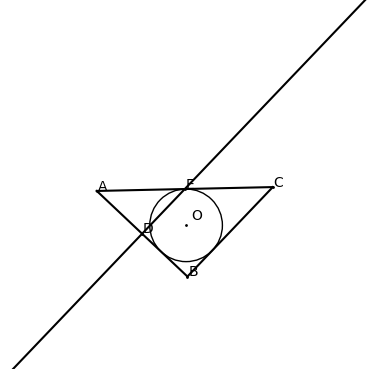

In [32]:
sample = next(iter(ds))
display(sample["image"])

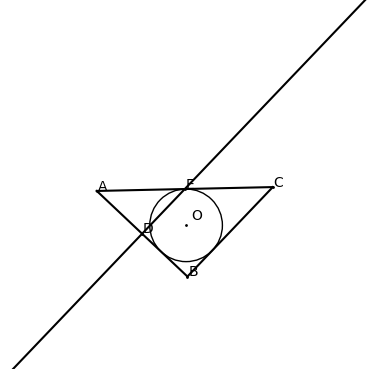

triangle ABC, angle ABC = 90, angle BAC = 45, angle ACB = 45, point D is the midpoint of segment AB, point E is the midpoint of segment AC, line DE, angle ADE = 90, circle D with diameter AB


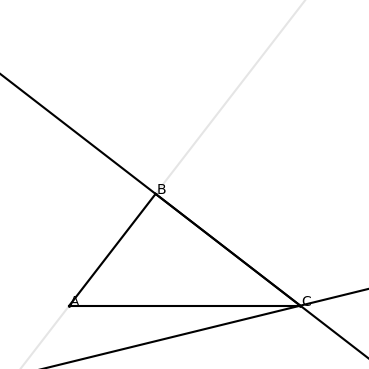

triangle ABC, angle ABC = 90, angle BAC = 60, angle ACB = 30, a line through point C is perpendicular to segment BC, a line through point B is perpendicular to segment AC


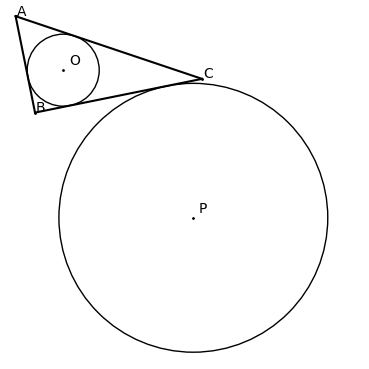

triangle ABC, AB = AC, point D is on segment AB, point E is on segment AC, and point F is on segment BC, BC // DE, AC // DF, line DF


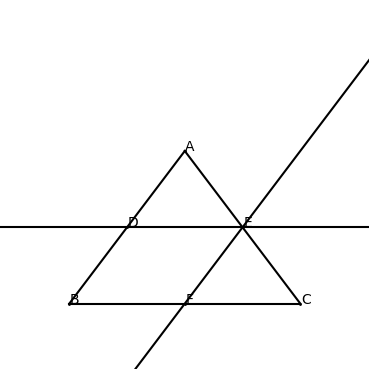

rectangle ABCD, a line through point A


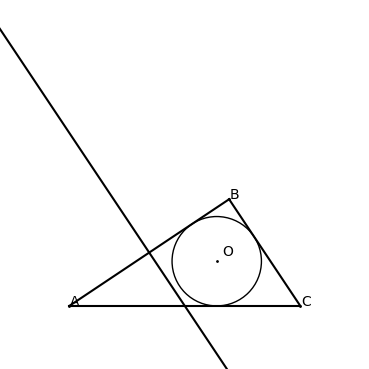

triangle ABC, angle ABC = 90, angle BAC = 45, angle ACB = 45, point D is on segment AB, point E is on on segment AC, point F is on segment BC, line DE, line DF, BC // DE, AC // DF


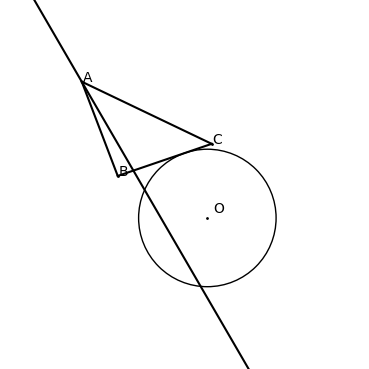

triangle ABC, angle ABC = 90, circumcircle O of triangle ABC, point N is on the circle O, diameter AC


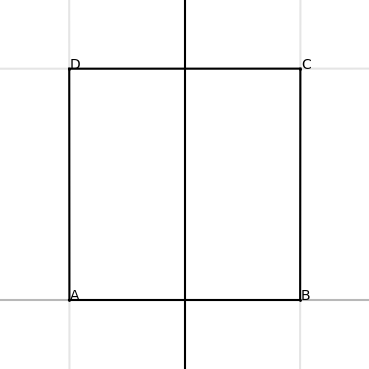

triangle ABC, angle ABC = 90, incircle O of triangle ABC, point N is on the circle O


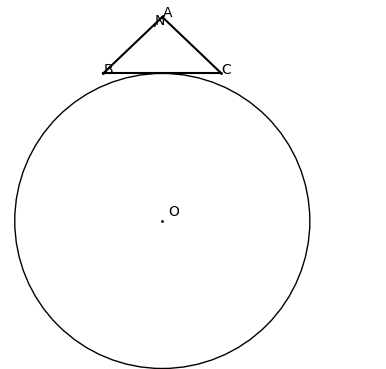

triangle ABC, angle ABC = 90, angle BAC = 45, angle ACB = 45, a line through point B and point C


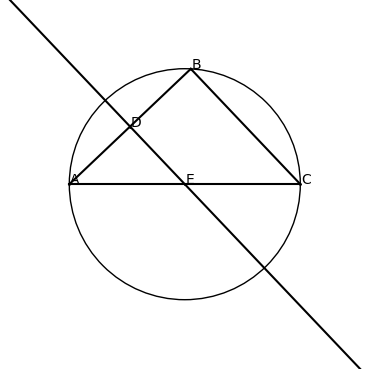

triangle ABC, angle ABC = 90, excircle O of triangle ABC is tangent to segment BC, point N is on the circle O


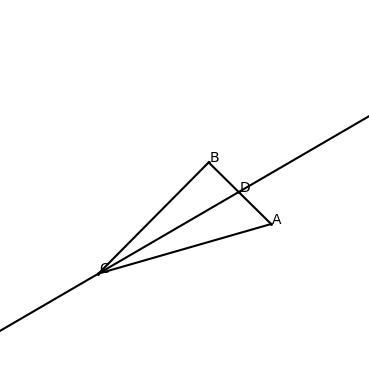

triangle ABC, angle ABC = 90, angle BAC = 60, angle ACB = 30, incircle O of triangle ABC


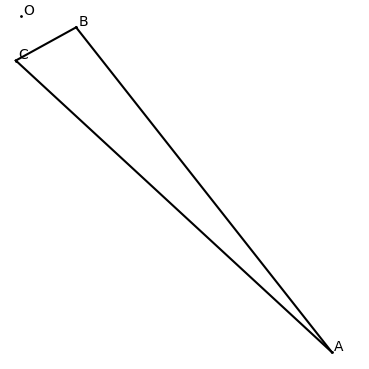

triangle ABC, AB = AC, circle O with diameter BC


In [73]:
from pathlib import Path

output_dir = Path("/content/diagram_train")
output_dir.mkdir(exist_ok=True, parents=True)
limit = 10

for i, (img_sample, text_sample) in enumerate(zip(ds, diagram_texts)):
    image = img_sample["image"]
    text  = text_sample["caption"]
    id = text_sample["id"]

    filename = output_dir / f"img_{id}.png"

    display(image)
    print(text)

    image.save(filename)

    if i == limit:
      break

## Translate

In [79]:
translation_rules = [
    # 1. FIXED PHRASES & QUANTIFIERS
    # Must be processed first to avoid grammatical conflicts
    ("two concentric circles", "hai đường tròn đồng tâm"),
    ("three concentric circles", "ba đường tròn đồng tâm"),
    ("concentric circles", "các đường tròn đồng tâm"),
    ("perpendicular bisector", "đường trung trực"),
    ("is perpendicular to", "vuông góc với"),
    ("is parallel to", "song song với"),
    ("is tangent to", "tiếp xúc với"),
    ("is similar to", "đồng dạng với"),
    ("is congruent to", "bằng"),
    ("is inside", "nằm trong"),

    # 2. LONG GEOMETRIC TERMS
    ("equilateral triangle", "tam giác đều"),
    ("isosceles triangle", "tam giác cân"),
    ("right triangle", "tam giác vuông"),
    ("circumcircle", "đường tròn ngoại tiếp"),
    ("circumcenter", "tâm đường tròn ngoại tiếp"),
    ("incircle", "đường tròn nội tiếp"),
    ("incenter", "tâm đường tròn nội tiếp"),
    ("excircle", "đường tròn bàng tiếp"),
    ("excenter", "tâm đường tròn bàng tiếp"),
    ("parallelogram", "hình bình hành"),
    ("quadrilateral", "tứ giác"),
    ("rectangle", "hình chữ nhật"),
    ("trapezoid", "hình thang"),
    ("pentagon", "ngũ giác"),

    # 3. COMMON ERROR FIXES
    ("extension of", "phần kéo dài của"),
    ("extension", "phần kéo dài"),
    ("centroid of", "trọng tâm của"),
    ("centroid", "trọng tâm"),
    ("diagonal", "đường chéo"),

    # 4. PLURAL NOUNS
    # Must be handled before singulars to avoid malformed words
    ("circles", "các đường tròn"),
    ("angles", "các góc"),
    ("segments", "các đoạn thẳng"),
    ("lines", "các đường thẳng"),
    ("rays", "các tia"),
    ("points", "các điểm"),

    # 5. SINGULAR NOUNS
    ("circle", "đường tròn"),
    ("angle", "góc"),
    ("segment", "đoạn thẳng"),
    ("line", "đường thẳng"),
    ("ray", "tia"),
    ("point", "điểm"),
    ("diameter", "đường kính"),
    ("radius", "bán kính"),
    ("triangle", "tam giác"),
    ("square", "hình vuông"),

    # 6. CONNECTORS & PREPOSITIONS
    ("is the", "là"),
    ("is on", "nằm trên"),
    ("intersects", "cắt"),
    ("intersect", "cắt"),
    ("through", "đi qua"),
    ("midpoint of", "trung điểm của"),
    ("with", "với"),
    ("and", "và"),
    ("of", "của"),
    ("at", "tại"),

    # 7. NUMBERS
    ("two", "hai"),
    ("three", "ba"),
    ("one", "một")
]

# Special geometry symbols
symbol_map = {
    "⊥": "vuông góc với",
    "//": "song song với"
}

def translate_geometry(text):
    # STEP 1: REMOVE INDEFINITE ARTICLE "a"
    # Prevent incorrect translations like "điểm một"
    # Only remove lowercase 'a' not followed by uppercase letter (Point A)
    text = re.sub(r'\ba\s+(?![A-Z])', '', text)

    # Handle sentence starting with "A line ..." → "Line ..."
    text = re.sub(r'^A\s+(?=[a-z])', '', text)

    # STEP 2: APPLY TRANSLATION RULES SEQUENTIALLY
    # Order matters – rules are applied top-down
    for en_term, vn_term in translation_rules:
        pattern = re.compile(
            r'\b' + re.escape(en_term) + r'\b',
            re.IGNORECASE
        )
        text = pattern.sub(vn_term, text)

    # STEP 3: REPLACE SPECIAL SYMBOLS
    for sym, val in symbol_map.items():
        text = text.replace(sym, val)

    # STEP 4: POST-PROCESSING GRAMMAR FIXES
    # Remove "các" after numbers: "ba các đường tròn" → "ba đường tròn"
    text = re.sub(
        r'(hai|ba|bốn|năm)\s+các\s+',
        r'\1 ',
        text,
        flags=re.IGNORECASE
    )

    # Remove unnecessary determiners
    text = re.sub(r'\b(the|that)\b', '', text, flags=re.IGNORECASE)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Capitalize first letter
    if text:
        text = text[0].upper() + text[1:]

    return text


for text in tqdm(diagram_texts, desc="Translating"):
    eng_caption = text["caption"]
    text["vn_caption"] = translate_geometry(eng_caption)

diagram_texts[0]

Translating:   0%|          | 0/22832 [00:00<?, ?it/s]

{'image': 'val/img_1.png',
 'id': 1,
 'caption': 'triangle ABC, angle ABC = 90, angle BAC = 45, angle ACB = 45, point D is the midpoint of segment AB, point E is the midpoint of segment AC, line DE, angle ADE = 90, circle D with diameter AB',
 'vn_caption': 'Tam giác ABC, góc ABC = 90, góc BAC = 45, góc ACB = 45, điểm D là trung điểm của đoạn thẳng AB, điểm E là trung điểm của đoạn thẳng AC, đường thẳng DE, góc ADE = 90, đường tròn D với đường kính AB'}